In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score
import joblib

Se carga la información del dataset

In [6]:
data = pd.read_csv("../03_datasets/train_dataset_base.csv")

Se revisan los campos y sus formatos

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13044 entries, 0 to 13043
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   subtitle            13044 non-null  object 
 1   sq_mt_built         13044 non-null  float64
 2   n_rooms             13044 non-null  int64  
 3   n_bathrooms         13044 non-null  float64
 4   floor               13044 non-null  int64  
 5   is_floor_under      13044 non-null  bool   
 6   rent_price          13044 non-null  int64  
 7   buy_price           13044 non-null  int64  
 8   buy_price_by_area   13044 non-null  int64  
 9   house_type_id       13044 non-null  object 
 10  is_renewal_needed   13044 non-null  bool   
 11  is_new_development  13044 non-null  bool   
 12  has_lift            13044 non-null  bool   
 13  is_exterior         13044 non-null  bool   
 14  energy_certificate  13044 non-null  object 
 15  has_parking         13044 non-null  bool   
 16  Prec

Se chequea una pequeña muestra del dataset para ver el tipo de datos

In [8]:
data.sort_values("Distrito")

,subtitle,sq_mt_built,n_rooms,n_bathrooms,floor,is_floor_under,rent_price,buy_price,buy_price_by_area,house_type_id,is_renewal_needed,is_new_development,has_lift,is_exterior,energy_certificate,has_parking,Precio_por_m2,Distrito
8650,Arganzuela,125.0,3,2.0,1,False,1683,506996,4056,Pisos,False,True,True,True,other,True,3972.60,Arganzuela
4898,Acacias,65.0,2,1.0,2,False,948,210000,3231,Pisos,False,False,False,True,other,False,4208.00,Arganzuela
3507,Delicias,150.0,3,2.0,1,False,2081,680000,4533,Pisos,False,False,True,True,other,True,3972.60,Arganzuela
4312,Acacias,113.0,3,2.0,1,False,1574,459000,4062,Pisos,False,False,True,True,other,True,4208.00,Arganzuela
9232,Legazpi,83.0,2,2.0,1,False,1299,340000,4096,Pisos,False,False,True,True,other,True,4486.93,Arganzuela
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6017,Villaverde,70.0,2,1.0,1,False,494,89990,1286,Pisos,False,False,True,True,other,False,1617.18,Villaverde
1167,Butarque,55.0,2,1.0,2,False,539,99900,1816,Pisos,False,False,False,True,F,False,2197.80,Villaverde
10178,San Andrés,91.0,2,2.0,1,False,964,215000,2363,Pisos,False,False,True,True,other,True,1617.18,Villaverde
11298,San Andrés,120.0,3,1.0,4,False,851,180000,1500,Pisos,True,False,False,True,E,False,1617.18,Villaverde


## Análisis de Datos Numéricos

Se revisan los estadísticos básicos.

In [9]:
data.describe()

,sq_mt_built,n_rooms,n_bathrooms,floor,rent_price,buy_price,buy_price_by_area,Precio_por_m2
count,13044.000000,13044.000000,13044.000000,13044.000000,1.304400e+04,1.304400e+04,13044.000000,13044.000000
mean,145.516099,2.996550,2.088086,2.170653,-6.926133e+04,6.540890e+05,4018.785649,3801.528573
std,132.052865,1.493497,1.406870,2.280595,1.042780e+06,7.964898e+05,1917.184468,1451.584086
min,16.000000,0.000000,1.000000,-1.000000,-3.459028e+07,3.600000e+04,688.000000,1308.890000
25%,70.000000,2.000000,1.000000,1.000000,7.217500e+02,1.980000e+05,2541.000000,2443.620000
50%,100.000000,3.000000,2.000000,2.000000,1.116000e+03,3.714190e+05,3719.000000,3810.080000
75%,160.000000,4.000000,2.000000,4.000000,1.667000e+03,7.550000e+05,5000.000000,4807.690000
max,999.000000,24.000000,16.000000,9.000000,2.517000e+03,8.800000e+06,18889.000000,8392.430000


Se observa que en **rent_price** hay valores por debajo de 0, por lo que se podría considerar como errores que afectan los demás indicadores. Se deben encontrar y remover del dataset.

In [10]:
errors_in_rent_price = data.loc[data["rent_price"] <= 0]
errors_in_rent_price

,subtitle,sq_mt_built,n_rooms,n_bathrooms,floor,is_floor_under,rent_price,buy_price,buy_price_by_area,house_type_id,is_renewal_needed,is_new_development,has_lift,is_exterior,energy_certificate,has_parking,Precio_por_m2,Distrito
9,Chamberí,432.0,6,2.0,-1,False,-221,1395000,3229,Pisos,False,False,False,True,E,False,4548.30,Chamberí
14,Barrio de Salamanca,201.0,3,4.0,2,False,-44765,2150000,10697,Pisos,False,False,True,True,other,False,8392.43,Salamanca
24,Tetuán,398.0,7,5.0,8,False,-65933,2300000,5779,Pisos,True,False,True,True,other,True,4347.59,Tetuán
30,Aravaca,855.0,5,8.0,-1,False,-84370,2404800,2813,Casa o chalet,False,False,True,True,other,False,3600.40,Moncloa
48,San Juan Bautista,238.0,4,2.0,2,False,-4705,1585000,6660,Pisos,False,True,True,True,other,True,4098.70,Ciudad Lineal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13024,Jerónimos,392.0,4,4.0,3,False,-323352,3120000,7959,Pisos,False,False,True,True,other,True,6739.32,Retiro
13029,Moncloa,600.0,5,5.0,-1,False,-266250,3000000,5000,Casa o chalet,False,False,True,True,other,True,3600.40,Moncloa
13035,Argüelles,509.0,7,4.0,4,False,-26621,1975000,3880,Pisos,False,False,True,True,other,True,4807.69,Moncloa
13041,Chamartín,295.0,5,4.0,3,False,-2096,1490000,5051,Pisos,True,False,True,True,other,False,6255.45,Chamartín


In [11]:
data.drop(errors_in_rent_price.index, inplace=True)
data.describe()

,sq_mt_built,n_rooms,n_bathrooms,floor,rent_price,buy_price,buy_price_by_area,Precio_por_m2
count,11454.000000,11454.000000,11454.000000,11454.000000,11454.000000,1.145400e+04,11454.000000,11454.000000
mean,111.524533,2.721233,1.743758,2.258338,1341.845818,4.166673e+05,3729.842239,3596.602120
std,70.191202,1.217788,0.921759,2.206421,584.067247,2.959156e+05,1627.870338,1325.860211
min,16.000000,0.000000,1.000000,-1.000000,18.000000,3.600000e+04,688.000000,1308.890000
25%,67.000000,2.000000,1.000000,1.000000,851.000000,1.802750e+05,2419.000000,2319.440000
50%,92.000000,3.000000,2.000000,2.000000,1213.000000,3.180000e+05,3511.000000,3600.400000
75%,133.000000,3.000000,2.000000,4.000000,1781.000000,5.750000e+05,4676.000000,4486.930000
max,800.000000,13.000000,13.000000,9.000000,2517.000000,1.380000e+06,17692.000000,8392.430000


**Nota:** Se observa que los valores de las variables **buy_price, rent_price** tienen una valor relativamente alto para el manejo y entrenamiento de un modelo de ML/DL. Por lo que se podría usar una transformación de logaritmo sobre estos campos que se podrían considerar como targets.

In [12]:
df = data.copy(deep=True)
df["buy_price_log"] = np.log1p(df["buy_price"])
df["rent_price_log"] = np.log1p(df["rent_price"])

In [13]:
df.describe()

,sq_mt_built,n_rooms,n_bathrooms,floor,rent_price,buy_price,buy_price_by_area,Precio_por_m2,buy_price_log,rent_price_log
count,11454.000000,11454.000000,11454.000000,11454.000000,11454.000000,1.145400e+04,11454.000000,11454.000000,11454.000000,11454.000000
mean,111.524533,2.721233,1.743758,2.258338,1341.845818,4.166673e+05,3729.842239,3596.602120,12.698221,7.101864
std,70.191202,1.217788,0.921759,2.206421,584.067247,2.959156e+05,1627.870338,1325.860211,0.702215,0.465393
min,16.000000,0.000000,1.000000,-1.000000,18.000000,3.600000e+04,688.000000,1308.890000,10.491302,2.944439
25%,67.000000,2.000000,1.000000,1.000000,851.000000,1.802750e+05,2419.000000,2319.440000,12.102244,6.747587
50%,92.000000,3.000000,2.000000,2.000000,1213.000000,3.180000e+05,3511.000000,3600.400000,12.669810,7.101676
75%,133.000000,3.000000,2.000000,4.000000,1781.000000,5.750000e+05,4676.000000,4486.930000,13.262127,7.485492
max,800.000000,13.000000,13.000000,9.000000,2517.000000,1.380000e+06,17692.000000,8392.430000,14.137595,7.831220


In [14]:
df.corr(numeric_only=True)

,sq_mt_built,n_rooms,n_bathrooms,floor,is_floor_under,rent_price,buy_price,buy_price_by_area,is_renewal_needed,is_new_development,has_lift,is_exterior,has_parking,Precio_por_m2,buy_price_log,rent_price_log
sq_mt_built,1.000000,0.682126,0.798701,-0.080097,-0.139246,0.606374,0.780375,0.006245,0.064433,0.046458,0.296971,0.172085,0.381286,0.200742,0.711057,0.523141
n_rooms,0.682126,1.000000,0.630427,0.015139,-0.184737,0.442838,0.521359,-0.127749,0.188610,-0.023752,0.156903,0.173128,0.201788,0.048753,0.484771,0.383564
n_bathrooms,0.798701,0.630427,1.000000,-0.056703,-0.133621,0.603420,0.731688,0.140683,-0.004155,0.097039,0.330077,0.133780,0.392776,0.233458,0.690176,0.533517
floor,-0.080097,0.015139,-0.056703,1.000000,-0.421885,0.118982,0.058301,0.155206,0.041646,-0.082859,0.150110,0.012673,0.059311,0.091766,0.105645,0.139543
is_floor_under,-0.139246,-0.184737,-0.133621,-0.421885,1.000000,-0.205445,-0.177319,-0.116964,0.010844,-0.049655,-0.142846,-0.091185,-0.129338,-0.053597,-0.215632,-0.216207
rent_price,0.606374,0.442838,0.603420,0.118982,-0.205445,1.000000,0.819613,0.572506,0.020024,0.082552,0.459998,0.083181,0.313431,0.639656,0.904987,0.961130
buy_price,0.780375,0.521359,0.731688,0.058301,-0.177319,0.819613,1.000000,0.546869,0.046104,0.060553,0.406224,0.101465,0.332658,0.604263,0.942915,0.730583
buy_price_by_area,0.006245,-0.127749,0.140683,0.155206,-0.116964,0.572506,0.546869,1.000000,-0.056790,0.052145,0.335388,-0.154749,0.050229,0.800282,0.623187,0.578709
is_renewal_needed,0.064433,0.188610,-0.004155,0.041646,0.010844,0.020024,0.046104,-0.056790,1.000000,-0.129190,-0.032490,-0.035392,-0.117537,0.096076,0.018941,0.001765
is_new_development,0.046458,-0.023752,0.097039,-0.082859,-0.049655,0.082552,0.060553,0.052145,-0.129190,1.000000,0.146004,0.076993,0.142372,-0.074422,0.093840,0.097690


Comparamos con la data sin aplicar logaritmo

In [15]:
data.corr(numeric_only=True)

,sq_mt_built,n_rooms,n_bathrooms,floor,is_floor_under,rent_price,buy_price,buy_price_by_area,is_renewal_needed,is_new_development,has_lift,is_exterior,has_parking,Precio_por_m2
sq_mt_built,1.000000,0.682126,0.798701,-0.080097,-0.139246,0.606374,0.780375,0.006245,0.064433,0.046458,0.296971,0.172085,0.381286,0.200742
n_rooms,0.682126,1.000000,0.630427,0.015139,-0.184737,0.442838,0.521359,-0.127749,0.188610,-0.023752,0.156903,0.173128,0.201788,0.048753
n_bathrooms,0.798701,0.630427,1.000000,-0.056703,-0.133621,0.603420,0.731688,0.140683,-0.004155,0.097039,0.330077,0.133780,0.392776,0.233458
floor,-0.080097,0.015139,-0.056703,1.000000,-0.421885,0.118982,0.058301,0.155206,0.041646,-0.082859,0.150110,0.012673,0.059311,0.091766
is_floor_under,-0.139246,-0.184737,-0.133621,-0.421885,1.000000,-0.205445,-0.177319,-0.116964,0.010844,-0.049655,-0.142846,-0.091185,-0.129338,-0.053597
rent_price,0.606374,0.442838,0.603420,0.118982,-0.205445,1.000000,0.819613,0.572506,0.020024,0.082552,0.459998,0.083181,0.313431,0.639656
buy_price,0.780375,0.521359,0.731688,0.058301,-0.177319,0.819613,1.000000,0.546869,0.046104,0.060553,0.406224,0.101465,0.332658,0.604263
buy_price_by_area,0.006245,-0.127749,0.140683,0.155206,-0.116964,0.572506,0.546869,1.000000,-0.056790,0.052145,0.335388,-0.154749,0.050229,0.800282
is_renewal_needed,0.064433,0.188610,-0.004155,0.041646,0.010844,0.020024,0.046104,-0.056790,1.000000,-0.129190,-0.032490,-0.035392,-0.117537,0.096076
is_new_development,0.046458,-0.023752,0.097039,-0.082859,-0.049655,0.082552,0.060553,0.052145,-0.129190,1.000000,0.146004,0.076993,0.142372,-0.074422


Se grafica la variable **buy_price** antes y después de la transformación

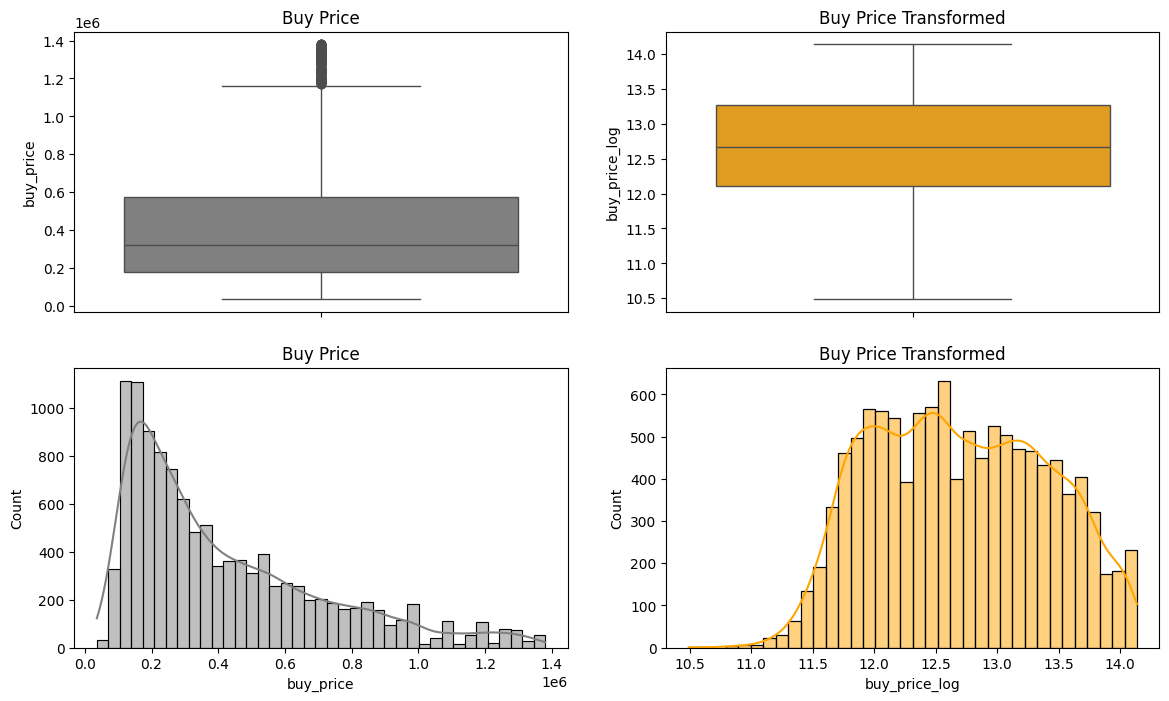

In [16]:
fig, ax = plt.subplots(2,2)
fig.set_size_inches(14,8)
sns.boxplot(data=data["buy_price"], ax=ax[0][0], color="grey")
ax[0][0].set_title("Buy Price")
sns.histplot(data=data["buy_price"], ax=ax[1][0], color="grey", kde=True)
ax[0][1].set_title("Buy Price Transformed")
sns.boxplot(data=df["buy_price_log"], ax=ax[0][1], color="orange")
ax[1][0].set_title("Buy Price")
sns.histplot(data=df["buy_price_log"], ax=ax[1][1], color="orange", kde=True)
ax[1][1].set_title("Buy Price Transformed")
plt.show()


Se puede observar que si no se transforma el target, comienzan a aparecer posibles outliers dada que la distancia entre puntuaciones es amplia en un determinado rango. Este tipo de problemática se resuelve por medio de la transformación aplicada que define mejor la distribución disminuyendo su sesgo.

In [17]:
q1_buy_price = data["buy_price"].quantile(0.25)
q3_buy_price = data["buy_price"].quantile(0.75)
IQR_buy_price = q3_buy_price - q1_buy_price
lower_bound = q1_buy_price - 1.5 * IQR_buy_price
upper_bound = q3_buy_price + 1.5 * IQR_buy_price
print(f"Q1: {q1_buy_price}")
print(f"Q3: {q3_buy_price}")
print(f"IQR: {IQR_buy_price}")
print(f"Límite inferior: {lower_bound}")
print(f"Límite inferior: {upper_bound}")

Q1: 180275.0
Q3: 575000.0
IQR: 394725.0
Límite inferior: -411812.5
Límite inferior: 1167087.5


In [18]:
print(f"Outliers antes de transformación: {len(data.loc[(data['buy_price'] < lower_bound) | (data['buy_price'] > upper_bound)])}")

Outliers antes de transformación: 358


In [19]:
q1_buy_price = df["buy_price_log"].quantile(0.25)
q3_buy_price = df["buy_price_log"].quantile(0.75)
IQR_buy_price = q3_buy_price - q1_buy_price
lower_bound = q1_buy_price - 1.5 * IQR_buy_price
upper_bound = q3_buy_price + 1.5 * IQR_buy_price
print(f"Q1: {q1_buy_price}")
print(f"Q3: {q3_buy_price}")
print(f"IQR: {IQR_buy_price}")
print(f"Límite inferior: {lower_bound}")
print(f"Límite inferior: {upper_bound}")

Q1: 12.10224402937439
Q3: 13.26212705890841
IQR: 1.1598830295340203
Límite inferior: 10.36241948507336
Límite inferior: 15.001951603209442


In [20]:
print(f"Outliers después de transformación: {len(df.loc[(df['buy_price_log'] < lower_bound) | (df['buy_price_log'] > upper_bound)])}")

Outliers después de transformación: 0


**Nota: Con los datos de **buy_price** transformados no hay outliers que remover.**

A continuación se realiza el mismo análisis con **rent_price**.

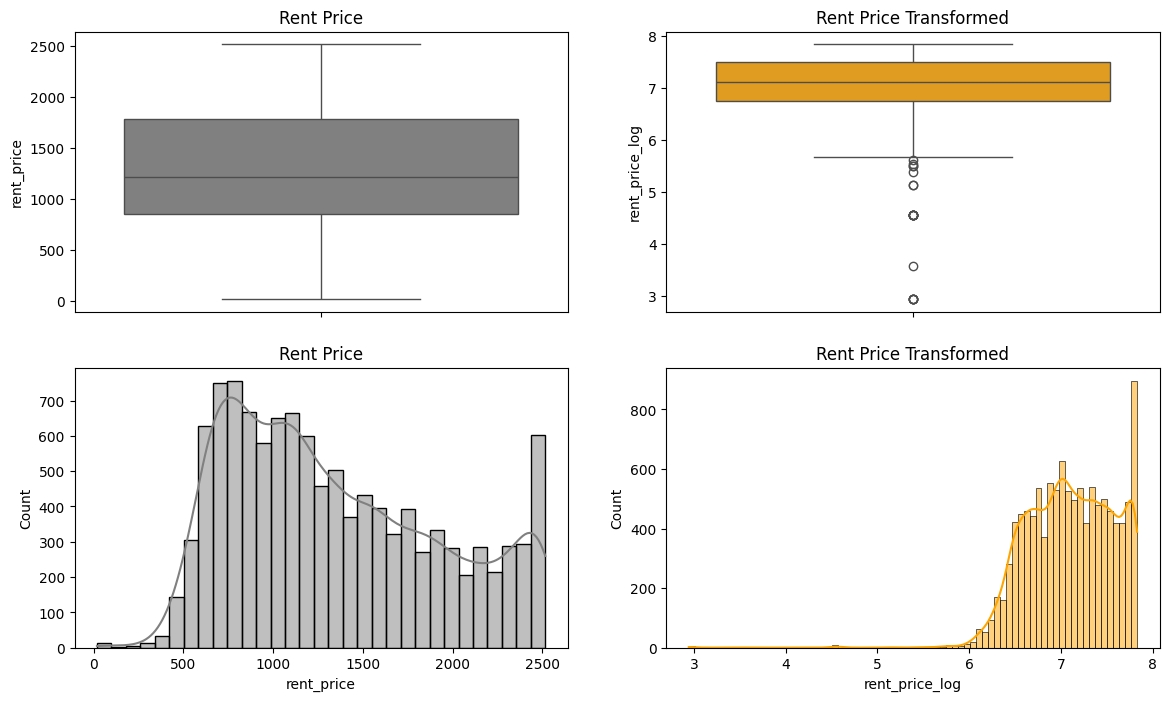

In [21]:
fig, ax = plt.subplots(2,2)
fig.set_size_inches(14,8)
sns.boxplot(data=data["rent_price"], ax=ax[0][0], color="grey")
ax[0][0].set_title("Rent Price")
sns.histplot(data=data["rent_price"], ax=ax[1][0], color="grey", kde=True)
ax[0][1].set_title("Rent Price Transformed")
sns.boxplot(data=df["rent_price_log"], ax=ax[0][1], color="orange")
ax[1][0].set_title("Rent Price")
sns.histplot(data=df["rent_price_log"], ax=ax[1][1], color="orange", kde=True)
ax[1][1].set_title("Rent Price Transformed")
plt.show()


En este caso se observa que podría resultar contraproducente dado que la distribución de los datos no mejora en definición. Por lo que se revierte la transformación.

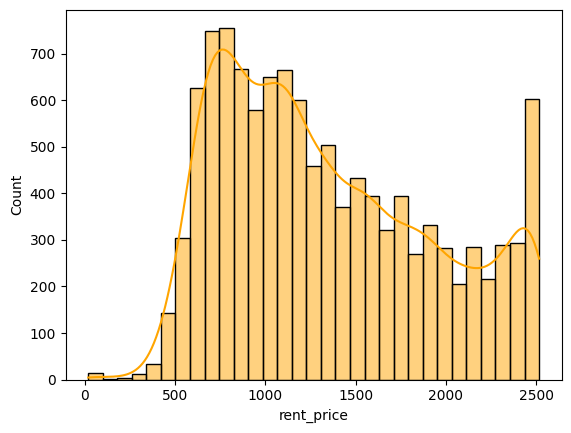

In [22]:
df.drop(columns="rent_price_log", inplace=True)
sns.histplot(data=df["rent_price"], color="orange", kde=True)
plt.show()

In [23]:
q1_buy_price = df["rent_price"].quantile(0.25)
q3_buy_price = df["rent_price"].quantile(0.75)
IQR_buy_price = q3_buy_price - q1_buy_price
lower_bound = q1_buy_price - 1.5 * IQR_buy_price
upper_bound = q3_buy_price + 1.5 * IQR_buy_price
print(f"Q1: {q1_buy_price}")
print(f"Q3: {q3_buy_price}")
print(f"IQR: {IQR_buy_price}")
print(f"Límite inferior: {lower_bound}")
print(f"Límite inferior: {upper_bound}")

Q1: 851.0
Q3: 1781.0
IQR: 930.0
Límite inferior: -544.0
Límite inferior: 3176.0


In [24]:
print(f"Outliers sin transformación: {len(df.loc[(df['rent_price'] < lower_bound) | (df['rent_price'] > upper_bound)])}")

Outliers sin transformación: 0


## X: n_bathrooms y n_rooms

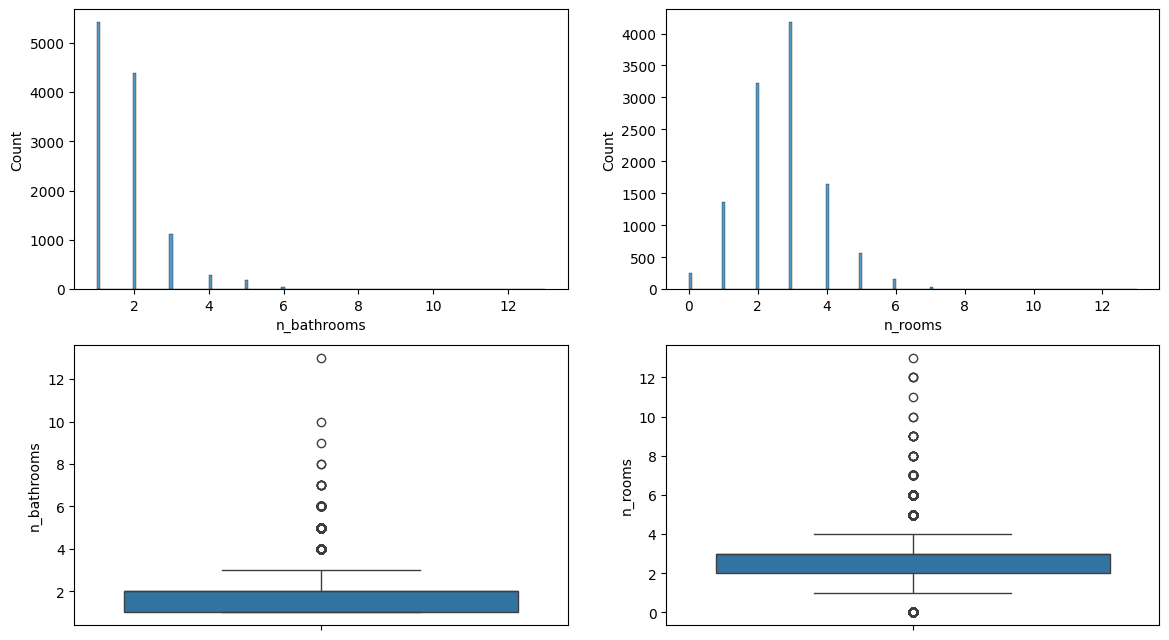

In [25]:
fig, ax = plt.subplots(2,2)
fig.set_size_inches(14,8)
sns.histplot(data=df["n_bathrooms"], ax=ax[0][0])
sns.boxplot(data=df["n_bathrooms"], ax=ax[1][0])
sns.histplot(data=df["n_rooms"], ax=ax[0][1])
sns.boxplot(data=df["n_rooms"], ax=ax[1][1])
plt.show()

Se calcula la matriz de correlación entre variables.

In [26]:
df.corr(numeric_only=True)

,sq_mt_built,n_rooms,n_bathrooms,floor,is_floor_under,rent_price,buy_price,buy_price_by_area,is_renewal_needed,is_new_development,has_lift,is_exterior,has_parking,Precio_por_m2,buy_price_log
sq_mt_built,1.000000,0.682126,0.798701,-0.080097,-0.139246,0.606374,0.780375,0.006245,0.064433,0.046458,0.296971,0.172085,0.381286,0.200742,0.711057
n_rooms,0.682126,1.000000,0.630427,0.015139,-0.184737,0.442838,0.521359,-0.127749,0.188610,-0.023752,0.156903,0.173128,0.201788,0.048753,0.484771
n_bathrooms,0.798701,0.630427,1.000000,-0.056703,-0.133621,0.603420,0.731688,0.140683,-0.004155,0.097039,0.330077,0.133780,0.392776,0.233458,0.690176
floor,-0.080097,0.015139,-0.056703,1.000000,-0.421885,0.118982,0.058301,0.155206,0.041646,-0.082859,0.150110,0.012673,0.059311,0.091766,0.105645
is_floor_under,-0.139246,-0.184737,-0.133621,-0.421885,1.000000,-0.205445,-0.177319,-0.116964,0.010844,-0.049655,-0.142846,-0.091185,-0.129338,-0.053597,-0.215632
rent_price,0.606374,0.442838,0.603420,0.118982,-0.205445,1.000000,0.819613,0.572506,0.020024,0.082552,0.459998,0.083181,0.313431,0.639656,0.904987
buy_price,0.780375,0.521359,0.731688,0.058301,-0.177319,0.819613,1.000000,0.546869,0.046104,0.060553,0.406224,0.101465,0.332658,0.604263,0.942915
buy_price_by_area,0.006245,-0.127749,0.140683,0.155206,-0.116964,0.572506,0.546869,1.000000,-0.056790,0.052145,0.335388,-0.154749,0.050229,0.800282,0.623187
is_renewal_needed,0.064433,0.188610,-0.004155,0.041646,0.010844,0.020024,0.046104,-0.056790,1.000000,-0.129190,-0.032490,-0.035392,-0.117537,0.096076,0.018941
is_new_development,0.046458,-0.023752,0.097039,-0.082859,-0.049655,0.082552,0.060553,0.052145,-0.129190,1.000000,0.146004,0.076993,0.142372,-0.074422,0.093840


## Análisis de Datos No Numéricos

### Bool Type

Se examinan las variables de tipo bool y se examinan si está o no balanceadas.

In [27]:
boolean_fields = df.select_dtypes(bool).columns

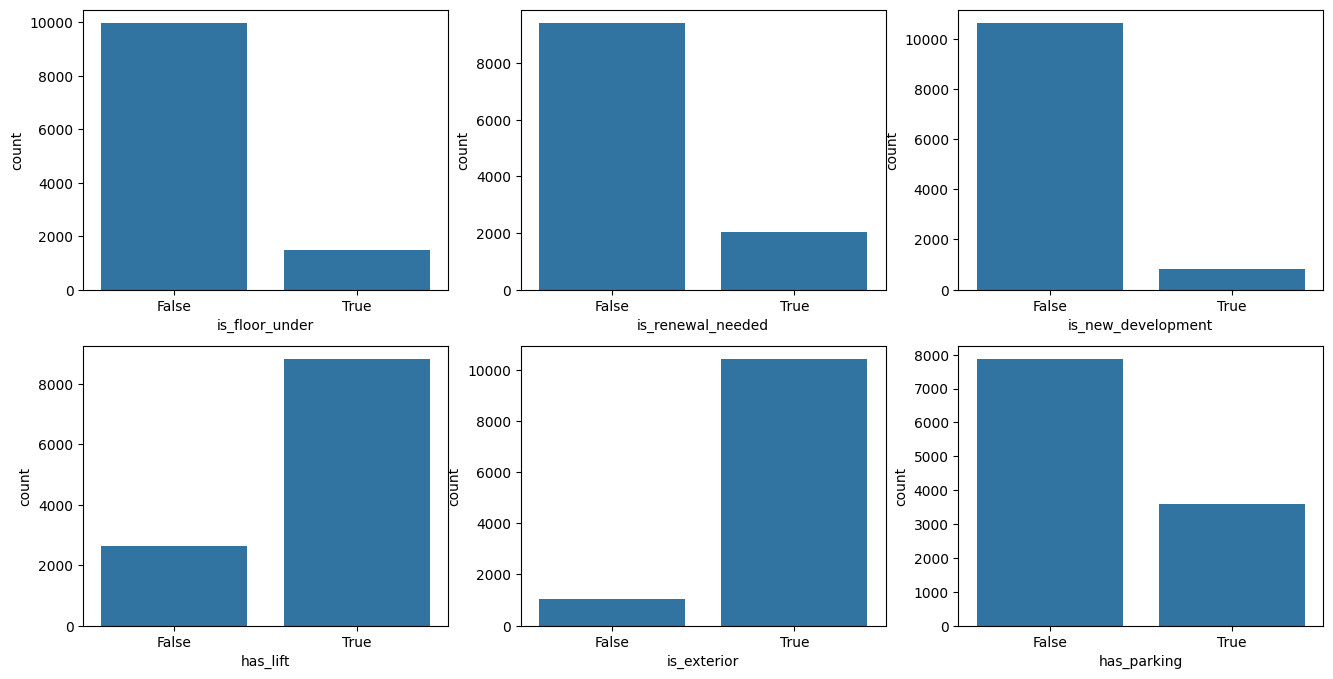

In [28]:
fig, ax = plt.subplots(2,3)
fig.set_size_inches(16,8)
for i, col in enumerate(boolean_fields):
    sns.countplot(data=df, x=col, ax=ax[i//3][i%3])
plt.show()

De lo antes presentado se puede deducir que las variables antes mencionadas no están balanceadas en ningún caso.

In [29]:
str_columns = df.select_dtypes(exclude=[bool,'number']).columns

In [30]:
for column in str_columns:
    print(df[column].value_counts(), "\n-------------------------------------------")

subtitle
Chamartín                           282
Centro                              259
Chamberí                            238
Moncloa                             232
Malasaña-Universidad                209
                                   ... 
Barajas                               5
El Pardo                              5
Campo de las Naciones-Corralejos      3
Casco Histórico de Barajas            2
Timón                                 2
Name: count, Length: 145, dtype: int64 
-------------------------------------------
house_type_id
Pisos            10083
Áticos             531
Casa o chalet      505
Dúplex             335
Name: count, dtype: int64 
-------------------------------------------
energy_certificate
other    7793
E        1419
D         563
G         527
F         387
C         282
A         273
B         210
Name: count, dtype: int64 
-------------------------------------------
Distrito
Centro                972
Carabanchel           921
Chamberí              830
C

In [31]:
df["price_checked"] = df["buy_price_by_area"] * df["sq_mt_built"]
print(f"Ratio de diferencia: ({((df['price_checked'].sum()/df['buy_price'].sum())-1)*100:.4f})%")
print(f"R2 estimado: {r2_score(df['buy_price'], df['price_checked'])}")

Ratio de diferencia: (0.0036)%
R2 estimado: 0.9999961527363278


De lo observado de los campos del dataset, se puede inferir que para efectos de una preparación de la data para ml se deberían transformar los datos de la siguiente manera:

- Las variables: **subtitle** y **Distrito** deberían usar el método de **Target Encoding**.
- Las variables: **house_type_id** deberían usar el método **One-Hot Encoding**.
- Las variables: **energy_certificate** deberían usar el método **Ordinal Encoding** (podría convertir a binaria). (Requiere transformación y verificación)
- Las variables: **is_floor_under**, **is_renewal_needed**, **is_new_development**, **has_lift**, **is_exterior**, **has_parking** solo deberían transformar sus valores **True en 1 y False en 0**.
- Las variables numéricas: **sq_mt_built**, **n_rooms**, **n_bathrooms**, **floor** se les puede aplicar un método de normalización o escalado, como **StandardScaler**.
- El Target: **buy_price** ha sidos transformado a una escala logaritmica de log1p.
- El Target: **rent_price** se mantendrá en su escala original.

### Variables a eliminar:
- La variable **buy_price_by_area** se podría elimninar por que suministra información que representa data leakage.
- La variable **Precio_por_m2** se podría eliminar porque tanto distrito como subtitle podrían suministrar la información similar e ésta.
- La variable ****rent_price_log**** se debe eliminar porque no aportaría una mejora en la distribución de datos.
- La variable ****price_checked**** se debe eliminar porque se uso para chequeo de datos.

# Preprocesamiento de de datos para ML/DL

In [32]:
from sklearn.preprocessing import TargetEncoder, OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [33]:
# Se eliminan las columnas "buy_price_by_area", "Precio_por_m2"
columns_to_drop = ["buy_price_by_area", "Precio_por_m2", "price_checked"]
df.drop(columns=columns_to_drop, inplace=True)

In [34]:
# Se definen las columnas y encoders aplicables

te_columns = ["subtitle", "Distrito"]

# oh_columns = ["house_type_id"]
oh_columns = ["house_type_id", "is_floor_under", "is_renewal_needed", "is_new_development", "has_lift", "is_exterior", "has_parking"]

oe_columns = ["energy_certificate"]
order = ["A", "B", "C", "D", "E", "F", "G", "other"]

ss_columns = ["sq_mt_built", "n_rooms", "n_bathrooms", "floor"]

X = df.drop(columns=["buy_price_log", "rent_price", "buy_price"])
y_1 = df["buy_price_log"]
y_2 = df["rent_price"]

preprocessor = ColumnTransformer(
    transformers=[
        ("te", TargetEncoder(), te_columns),
        ("oh", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False), oh_columns),
        ("oe", OrdinalEncoder(categories=[order]), oe_columns),
        ("ss", StandardScaler(), ss_columns)
    ]
)

preprocessor.set_output(transform="pandas")
Xtrain_df = preprocessor.fit_transform(X,y_1)

# Exportar preprocessor
joblib.dump(preprocessor, "../tools/preprocessor.joblib")

train_df = pd.concat([Xtrain_df, y_1, y_2], axis=1)
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11454 entries, 0 to 13042
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   te__subtitle                 11454 non-null  float64
 1   te__Distrito                 11454 non-null  float64
 2   oh__house_type_id_Dúplex     11454 non-null  float64
 3   oh__house_type_id_Pisos      11454 non-null  float64
 4   oh__house_type_id_Áticos     11454 non-null  float64
 5   oh__is_floor_under_True      11454 non-null  float64
 6   oh__is_renewal_needed_True   11454 non-null  float64
 7   oh__is_new_development_True  11454 non-null  float64
 8   oh__has_lift_True            11454 non-null  float64
 9   oh__is_exterior_True         11454 non-null  float64
 10  oh__has_parking_True         11454 non-null  float64
 11  oe__energy_certificate       11454 non-null  float64
 12  ss__sq_mt_built              11454 non-null  float64
 13  ss__n_rooms          

In [195]:
from tools.preprocessing import data_preprocessing

val_data = pd.read_csv("../datasets/val_dataset_base.csv")
val_data = data_preprocessing(val_data)
val_data.info()

<class 'pandas.DataFrame'>
Index: 3757 entries, 0 to 4348
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   subtitle            3757 non-null   str    
 1   sq_mt_built         3757 non-null   float64
 2   n_rooms             3757 non-null   int64  
 3   n_bathrooms         3757 non-null   float64
 4   floor               3757 non-null   int64  
 5   is_floor_under      3757 non-null   bool   
 6   rent_price          3757 non-null   int64  
 7   buy_price           3757 non-null   int64  
 8   house_type_id       3757 non-null   str    
 9   is_renewal_needed   3757 non-null   bool   
 10  is_new_development  3757 non-null   bool   
 11  has_lift            3757 non-null   bool   
 12  is_exterior         3757 non-null   bool   
 13  energy_certificate  3757 non-null   str    
 14  has_parking         3757 non-null   bool   
 15  Distrito            3757 non-null   str    
 16  buy_price_log       37

In [196]:
Xval_df = preprocessor.transform(val_data)
val_df = pd.concat([Xval_df, val_data[["buy_price_log", "rent_price"]]], axis=1)

In [197]:
val_df.info()

<class 'pandas.DataFrame'>
Index: 3757 entries, 0 to 4348
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   te__subtitle                 3757 non-null   float64
 1   te__Distrito                 3757 non-null   float64
 2   oh__house_type_id_Dúplex     3757 non-null   float64
 3   oh__house_type_id_Pisos      3757 non-null   float64
 4   oh__house_type_id_Áticos     3757 non-null   float64
 5   oh__is_floor_under_True      3757 non-null   float64
 6   oh__is_renewal_needed_True   3757 non-null   float64
 7   oh__is_new_development_True  3757 non-null   float64
 8   oh__has_lift_True            3757 non-null   float64
 9   oh__is_exterior_True         3757 non-null   float64
 10  oh__has_parking_True         3757 non-null   float64
 11  oe__energy_certificate       3757 non-null   float64
 12  ss__sq_mt_built              3757 non-null   float64
 13  ss__n_rooms                  3757 

In [198]:
test_data = pd.read_csv("../datasets/test_dataset_base.csv")
test_data = data_preprocessing(test_data)
test_data.info()

<class 'pandas.DataFrame'>
Index: 3707 entries, 0 to 4348
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   subtitle            3707 non-null   str    
 1   sq_mt_built         3707 non-null   float64
 2   n_rooms             3707 non-null   int64  
 3   n_bathrooms         3707 non-null   float64
 4   floor               3707 non-null   int64  
 5   is_floor_under      3707 non-null   bool   
 6   rent_price          3707 non-null   int64  
 7   buy_price           3707 non-null   int64  
 8   house_type_id       3707 non-null   str    
 9   is_renewal_needed   3707 non-null   bool   
 10  is_new_development  3707 non-null   bool   
 11  has_lift            3707 non-null   bool   
 12  is_exterior         3707 non-null   bool   
 13  energy_certificate  3707 non-null   str    
 14  has_parking         3707 non-null   bool   
 15  Distrito            3707 non-null   str    
 16  buy_price_log       37

In [199]:
Xtest_df = preprocessor.transform(test_data)
test_df = pd.concat([Xtest_df, test_data[["buy_price_log", "rent_price"]]], axis=1)

In [200]:
# SOLO PARA DEMOSTRACIÓN
preprocessor = joblib.load("../tools/preprocessor.joblib")
X_new_transformed = preprocessor.transform(test_data)

In [201]:
# SOLO PARA DEMOSTRACIÓN
print(X_new_transformed["te__subtitle"] == test_df["te__subtitle"])

0       True
1       True
2       True
4       True
5       True
        ... 
4343    True
4344    True
4346    True
4347    True
4348    True
Name: te__subtitle, Length: 3707, dtype: bool


In [202]:
test_df.info()

<class 'pandas.DataFrame'>
Index: 3707 entries, 0 to 4348
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   te__subtitle                 3707 non-null   float64
 1   te__Distrito                 3707 non-null   float64
 2   oh__house_type_id_Dúplex     3707 non-null   float64
 3   oh__house_type_id_Pisos      3707 non-null   float64
 4   oh__house_type_id_Áticos     3707 non-null   float64
 5   oh__is_floor_under_True      3707 non-null   float64
 6   oh__is_renewal_needed_True   3707 non-null   float64
 7   oh__is_new_development_True  3707 non-null   float64
 8   oh__has_lift_True            3707 non-null   float64
 9   oh__is_exterior_True         3707 non-null   float64
 10  oh__has_parking_True         3707 non-null   float64
 11  oe__energy_certificate       3707 non-null   float64
 12  ss__sq_mt_built              3707 non-null   float64
 13  ss__n_rooms                  3707 

### Exportar a csv

In [ ]:
train_df.to_csv("../03_datasets/train_data_prepared.csv", index=False)
val_df.to_csv("../03_datasets/val_data_prepared.csv", index=False)
test_df.to_csv("../03_datasets/test_data_prepared.csv", index=False)